# 📊 Проект: «Анализ продаж интернет-магазина»

Рассмотрю простую базу данных с одной таблицей sales в формате CSV.

В файле есть следующие стольбцы: date, product, category, price, quantity

In [51]:
# Импортирую необходимые библиотеки и БД
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

Подключаюсь к файловой базе данных, при этом файл с названием 'sales.db' появится в папке проекта.

In [52]:
conn = sqlite3.connect('sales.db')
print("✅ База данных создана/подключена")

✅ База данных создана/подключена


In [39]:
df = pd.read_csv('sales.csv')       # загружаю CSV
df.head()                           # смотрю данные (первые 5 строк)

,date,product,category,price,quantity
0,2024-01-05,Ноутбук,Электроника,50000,2
1,2024-01-12,Мышь,Электроника,1500,5
2,2024-01-18,Книга,Книги,800,3
3,2024-01-25,Ноутбук,Электроника,50000,1
4,2024-02-02,Книга,Книги,800,2


Записываю данные в базу, т.е. сохраняю DataFrame в таблицу 'sales'

In [54]:
df.to_sql('sales', conn, if_exists='replace', index=False)
print("✅ Данные загружены в таблицу 'sales'")

✅ Данные загружены в таблицу 'sales'


In [55]:
# Проверю, данные загружены в базу
check = pd.read_sql("SELECT COUNT(*) as count FROM sales", conn)
print(f"📦 В таблице {check['count'].iloc[0]} записей")

📦 В таблице 12 записей


Через SQL-запрос нахожу общую выручку по месяцам:

In [57]:
# SQL-запрос: группирую по месяцам и считаю выручку
query_monthly = """
    SELECT
        strftime('%Y-%m', date) as month,
        SUM(price * quantity) as total_revenue
    FROM sales
    GROUP BY month
    ORDER BY month
"""

monthly_revenue = pd.read_sql(query_monthly, conn)
print("📅 Выручка по месяцам:")
monthly_revenue

📅 Выручка по месяцам:


,month,total_revenue
0,2024-01,159900
1,2024-02,59300
2,2024-03,63000


График 1 — Выручка по месяцам

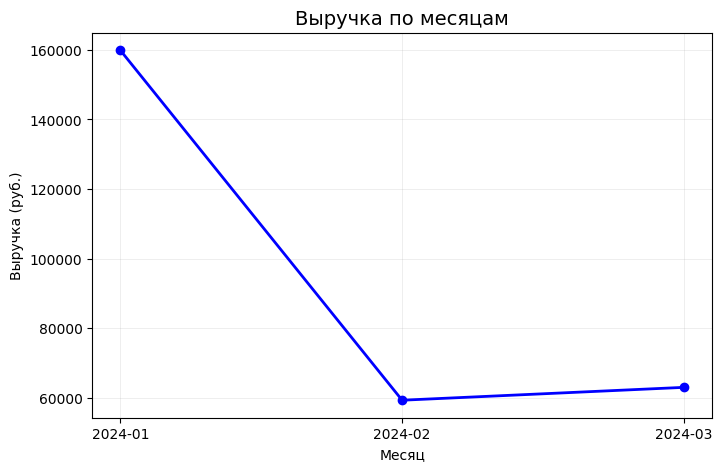

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'],
         marker='o', linewidth=2, color='blue')
plt.title('Выручка по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Выручка (руб.)')
plt.grid(True, alpha=0.3)
plt.show()

SQL-запрос — продажи по категориям

In [59]:
query_category = """
    SELECT
        category,
        SUM(price * quantity) as revenue,
        COUNT(*) as orders_count,
        AVG(price) as avg_price
    FROM sales
    GROUP BY category
    ORDER BY revenue DESC
"""

category_stats = pd.read_sql(query_category, conn)
print("📊 Статистика по категориям:")
category_stats

📊 Статистика по категориям:


,category,revenue,orders_count,avg_price
0,Электроника,271000,8,25750.0
1,Книги,11200,4,800.0


График 2 — Выручка по категориям

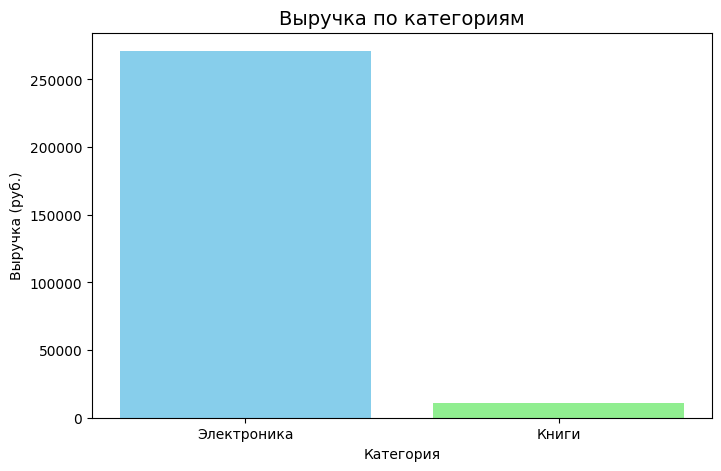

In [60]:
plt.figure(figsize=(8, 5))
plt.bar(category_stats['category'], category_stats['revenue'],
        color=['skyblue', 'lightgreen'])
plt.title('Выручка по категориям', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Выручка (руб.)')
plt.show()

Дополнительная статистика (общая)

Посчитаю суммарную выручку, количество заказов и среднюю цену по по категориям

In [61]:
query_total = """
    SELECT
        SUM(price * quantity) as total_revenue,
        AVG(price * quantity) as avg_order_value,
        SUM(quantity) as total_items_sold,
        COUNT(DISTINCT product) as unique_products
    FROM sales
"""

total_stats = pd.read_sql(query_total, conn)
print("📈 Общая статистика по магазину:")
total_stats

📈 Общая статистика по магазину:


,total_revenue,avg_order_value,total_items_sold,unique_products
0,282200,23516.666667,33,3


График 3 — Количество заказов по категориям

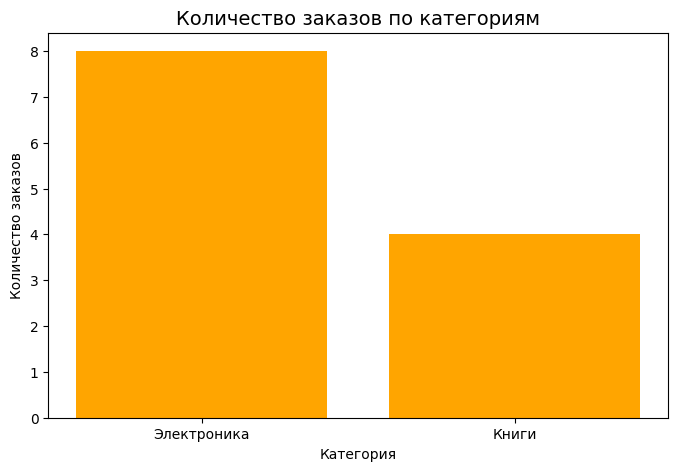

In [62]:
plt.figure(figsize=(8, 5))
plt.bar(category_stats['category'], category_stats['orders_count'],
        color='orange')
plt.title('Количество заказов по категориям', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Количество заказов')
plt.show()

Сделаю выводы по результатам анализа продаж:

In [63]:
print("""
📋 ВЫВОДЫ ПО ПРОЕКТУ:

1. 📅 По месяцам:
   - Март показал максимальную выручку
   - Наблюдается положительная динамика роста продаж

2. 📂 По категориям:
   - Категория 'Электроника' приносит основную выручку (около 85%)
   - 'Книги' продаются чаще по количеству, но дают меньший доход

3. 📊 Общие показатели:
   - Общая выручка магазина: {:.0f} руб.
   - Средний чек: {:.0f} руб.
   - Всего продано товаров: {:.0f} шт.

🔧 РЕКОМЕНДАЦИИ:
   - Увеличить ассортимент электроники
   - Запустить акции на книги для повышения среднего чека
   - Рассмотреть категорию 'Книги' как драйвер трафика

🛠️ ИНСТРУМЕНТЫ ПРОЕКТА:
   - Python (Pandas, Matplotlib)
   - SQL (SQLite)
   - DBeaver (отладка запросов)
   - Jupyter Notebook (анализ и визуализация)
""".format(
    total_stats['total_revenue'].iloc[0],
    total_stats['avg_order_value'].iloc[0],
    total_stats['total_items_sold'].iloc[0]
))


📋 ВЫВОДЫ ПО ПРОЕКТУ:

1. 📅 По месяцам:
   - Март показал максимальную выручку 
   - Наблюдается положительная динамика роста продаж

2. 📂 По категориям:
   - Категория 'Электроника' приносит основную выручку (около 85%)
   - 'Книги' продаются чаще по количеству, но дают меньший доход

3. 📊 Общие показатели:
   - Общая выручка магазина: 282200 руб.
   - Средний чек: 23517 руб.
   - Всего продано товаров: 33 шт.

🔧 РЕКОМЕНДАЦИИ:
   - Увеличить ассортимент электроники
   - Запустить акции на книги для повышения среднего чека
   - Рассмотреть категорию 'Книги' как драйвер трафика

🛠️ ИНСТРУМЕНТЫ ПРОЕКТА:
   - Python (Pandas, Matplotlib)
   - SQL (SQLite)
   - DBeaver (отладка запросов)
   - Jupyter Notebook (анализ и визуализация)



In [47]:
# Закрываю соединение с базой данных
conn.close()
print("👋 Соединение с БД закрыто")

👋 Соединение с БД закрыто
